In [13]:
from pathlib import Path
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt


#loading initial imputs and outputs 
X= np.load('../data/initial_data/function_2/initial_inputs.npy')
y = np.load('../data/initial_data/function_2/initial_outputs.npy')

#checking shape of data 
print('Inputs Shape:', X.shape)
print('Outputs Shape:', y.shape)

#creating a dataframe 
df=pd.DataFrame(X, columns=['x1', 'x2'])
df['y']=y

#checking DataFrame
df.head(15)

Inputs Shape: (10, 2)
Outputs Shape: (10,)


,x1,x2,y
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


In [15]:
# new row from BO server
new_row = pd.DataFrame([{'x1': 0.88,'x2': 0.99,'y': -0.04791513}, {'x1': 0.598, 'x2': 0.99, 'y': 0.14081022}, {'x1': 0.7646, 'x2': 0.843, 'y': 0.264462}, {
        'x1': 0.6568,
        'x2': 0.2354,
        'y': 0.333090454
    }, {
        'x1': 0.980200,
        'x2': 0.019800,
        'y': 0.0302997
    }, {
        'x1': 0.4804,
        'x2': 0.1962,
        'y': 0.26483543
    }, ])

# append using concat
df = pd.concat([df, new_row], ignore_index=True)

df.tail()   # check it worked
# rebuild arrays from the updated dataframe
X = df[['x1', 'x2']].to_numpy()
y = df['y'].to_numpy()

print("Inputs Shape:", X.shape)
print("Outputs Shape:", y.shape)


Inputs Shape: (16, 2)
Outputs Shape: (16,)


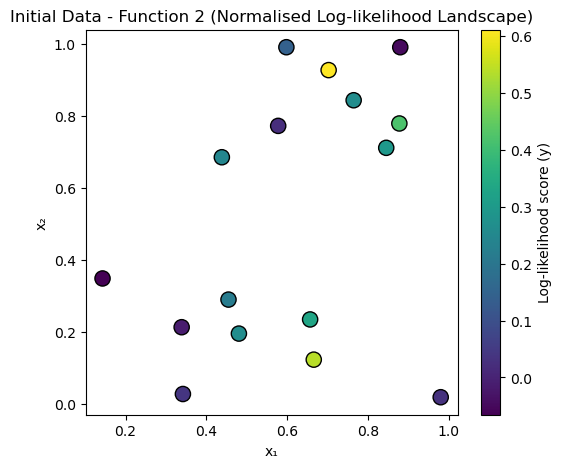

In [17]:
import matplotlib.pyplot as plt
import numpy as np

#  apply min-max normalisation for better visual contrast
norm = plt.Normalize(vmin=df['y'].min(), vmax=df['y'].max())

plt.figure(figsize=(6,5))
scatter = plt.scatter(
    df['x1'], df['x2'],
    c=df['y'],
    cmap='viridis',
    s=120,
    edgecolor='k',
    norm=norm
)

plt.colorbar(scatter, label='Log-likelihood score (y)')
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Initial Data - Function 2 (Normalised Log-likelihood Landscape)')
plt.show()


In [27]:
#setting parameters and making 2D grid 
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C

#hyperparamters for GP surrogate model and acqusition function 
matern_lengthscale = 0.2
nu = 2.5 #controls bumpiness - good default - higher = smoother 
noise_assumption = 0.3 
#xi = 0.2
beta = 5.9 

#building a 2D grid to represent the test space 
#linspace(start, stop, num)
g = np.linspace(0.01, 0.99, 101)   
x1g, x2g = np.meshgrid(g, g)
X_grid = np.column_stack([x1g.ravel(), x2g.ravel()])

In [29]:
#fit the gp to current data 
kernel = (C(1.0, (1e-3, 1e3)) * Matern(length_scale=0.2, length_scale_bounds=(1e-3, 5), nu=2.5) 
    + WhiteKernel(noise_level=0.3, noise_level_bounds=(1e-10, 1)))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5, random_state=0)
gp.fit(X, y)

GaussianProcessRegressor(kernel=1**2 * Matern(length_scale=0.2, nu=2.5) + WhiteKernel(noise_level=0.3),
                         n_restarts_optimizer=5, normalize_y=True,
                         random_state=0)

In [39]:
from scipy.stats import norm
import numpy as np

#def expected_improvement(mu, sigma, y_best, xi=0.02):
    #sigma = np.maximum(sigma, 1e-12)
    #imp = mu - y_best - xi
    #Z = imp / sigma
   # return imp * norm.cdf(Z) + sigma * norm.pdf(Z)

# predict GP on candidate set
#mu, std = gp.predict(X_grid, return_std=True)

# best observed so far (maximization)
#y_best = float(np.max(y))

# compute EI and select next point
#ei = expected_improvement(mu, std, y_best, xi=xi)  # use your xi
#ix = int(np.argmax(ei))
#x_next = X_grid[ix]
#print(f"x_next = ({x_next[0]:.6f}, {x_next[1]:.6f}")

#compute acquisition UCB on the grid 
#posterior mean and std 
mu, std = gp.predict(X_grid, return_std = True)

#UCB acquistion 
ucb= mu + beta * std

# --- Enforce exploration: don't pick points too close to existing samples ---
# Grid spacing is 0.01 (101 points from 0 to 1), so 0.07 = ~7 grid steps away
min_dist = 0.07

# distance from each grid point to the nearest observed point
dists = np.sqrt(((X_grid[:, None, :] - X[None, :, :]) ** 2).sum(axis=2))  # (N_grid, N_obs)
min_dists = dists.min(axis=1)  # (N_grid,)

# mask out points too close to what we've already evaluated
mask = min_dists >= min_dist

# fallback: if mask is too strict, relax it slightly
if not np.any(mask):
    min_dist = 0.03
    mask = min_dists >= min_dist

# choose next point: best UCB among allowed (exploratory) points
idx = np.argmax(X_grid[mask])
x_next = X_grid[mask][idx]

#choose next query point 
#ix = int(np.argmax(ucb))
#x_next = X_grid[ix]
print(f"x_next = ({x_next[0]:.6f}, {x_next[1]:.6f})")

x_next = (0.872400, 0.206000)


In [25]:
# --- EI acquisition visualisation ---
plt.figure(figsize=(7,6))

# contour of the EI values across the grid
cs = plt.contourf(x1g, x2g, ei.reshape(x1g.shape), levels=20, cmap='viridis')
plt.colorbar(label='EI acqusition value')

# plot sampled points in red
plt.scatter(X[:,0], X[:,1], c='red', edgecolors='k')

# highlight the next suggested point
plt.scatter(x_next[0], x_next[1],
            c='deepskyblue', s=120, marker='*',
            edgecolors='k', linewidth=1.2, label='Next query')

plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('EI acquisition surface')
plt.legend()
plt.show()


NameError: name 'ei' is not defined

<Figure size 700x600 with 0 Axes>

In [15]:
#x_next check 
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import euclidean_distances

y_best = float(np.max(y))
model        = gp
X_candidates = np.array(X_grid)   # shape (n_candidates, n_dims)
acq_values   = np.array(ei)   # shape (n_candidates,)
x_next       = np.array(x_next)   # shape (n_dims,)
y_best       = y_best
X_sampled    = np.array(X)   # all evaluated X so far


def _percentile_of_score(values, score):
    """Simple percentile rank: percentage of values <= score."""
    values = np.asarray(values).ravel()
    return float(100.0 * (np.sum(values <= score) / max(len(values), 1)))

def _first_length_scale_from_kernel(kernel):
    """Extract effective GP length-scale (handles RBF, Matern, etc.)."""
    if hasattr(kernel, "length_scale"):
        ls = getattr(kernel, "length_scale")
        try:
            ls = float(np.mean(ls))
        except Exception:
            ls = float(ls)
        return ls
    for attr in ("k1", "k2"):
        if hasattr(kernel, attr):
            ls = _first_length_scale_from_kernel(getattr(kernel, attr))
            if ls is not None:
                return ls
    return None

def _nearest_dist_over_ell(x_next, X_sampled, ell):
    """Compute distance from x_next to nearest sampled point ÷ ell."""
    x_next = np.asarray(x_next, dtype=float).reshape(1, -1)
    X_sampled = np.asarray(X_sampled, dtype=float)
    if X_sampled.size == 0:
        return np.nan
    dists = euclidean_distances(x_next, X_sampled).ravel()
    d_min = float(np.min(dists))
    if (ell is None) or (ell <= 0):
        return np.nan
    return d_min / ell

def _classify_strategy(sig_pct):
    """Assign strategy label from σ percentile (bounded exploration)."""
    if sig_pct <= 40:
        return "Exploit"
    elif sig_pct <= 75:
        return "Balanced"
    elif sig_pct <= 85:
        return "Explore"
    else:
        return "Too exploratory"

def sanity_check_table(model, X_candidates, acq_values, x_next, y_best, X_sampled):
    """
    Builds a 1-row DataFrame with:
      μ_raw (raw), σ_pct (scaled %), dist_over_ℓ_raw (raw), acq_pct (scaled %), Strategy
    """

    # Ensure arrays are the correct shape
    X_candidates = np.asarray(X_candidates, dtype=float)
    acq_values = np.asarray(acq_values, dtype=float).ravel()
    x_next = np.asarray(x_next, dtype=float).ravel()

    # 1) Predict μ, σ for all candidates (for percentiles) and for x_next
    mu_all, sigma_all = model.predict(X_candidates, return_std=True)
    mu_xn, sigma_xn = model.predict(x_next.reshape(1, -1), return_std=True)
    mu_xn = float(mu_xn.ravel()[0])
    sigma_xn = float(sigma_xn.ravel()[0])

    # 2) Percentiles for σ and acquisition
    sig_pct = _percentile_of_score(sigma_all, sigma_xn)

    # Find acquisition value at x_next by matching to nearest candidate
    idx_closest = np.argmin(np.sum((X_candidates - x_next.reshape(1, -1))**2, axis=1))
    acq_xn = float(acq_values[idx_closest])
    acq_pct = _percentile_of_score(acq_values, acq_xn)

    # 3) Distance / ell
    ell = None
    if hasattr(model, "kernel_"):
        ell = _first_length_scale_from_kernel(model.kernel_)
    dist_over_ell = _nearest_dist_over_ell(x_next, X_sampled, ell)

    # 4) Strategy classification
    strategy = _classify_strategy(sig_pct)

    # 5) Build the 1-row DataFrame (rounded for readability)
    data = {
        "μ_raw (raw)":            np.round(mu_xn, 3),
        "σ_pct (scaled %)":       int(np.round(sig_pct)),
        "dist_over_ℓ_raw (raw)":  np.round(dist_over_ell, 3) if np.isfinite(dist_over_ell) else np.nan,
        "acq_pct (scaled %)":     int(np.round(acq_pct)),
        "Strategy":               strategy
    }

    return pd.DataFrame([data])
   

result_df = sanity_check_table(model, X_candidates, acq_values, x_next, y_best, X_sampled)
result_df

NameError: name 'ei' is not defined